In [ ]:
!pip install ultralytics

Please upload an image file:


Saving image8.jpg to image8.jpg

0: 480x640 1 person, 3 cars, 1 motorcycle, 1 bus, 270.9ms
Speed: 11.0ms preprocess, 270.9ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)


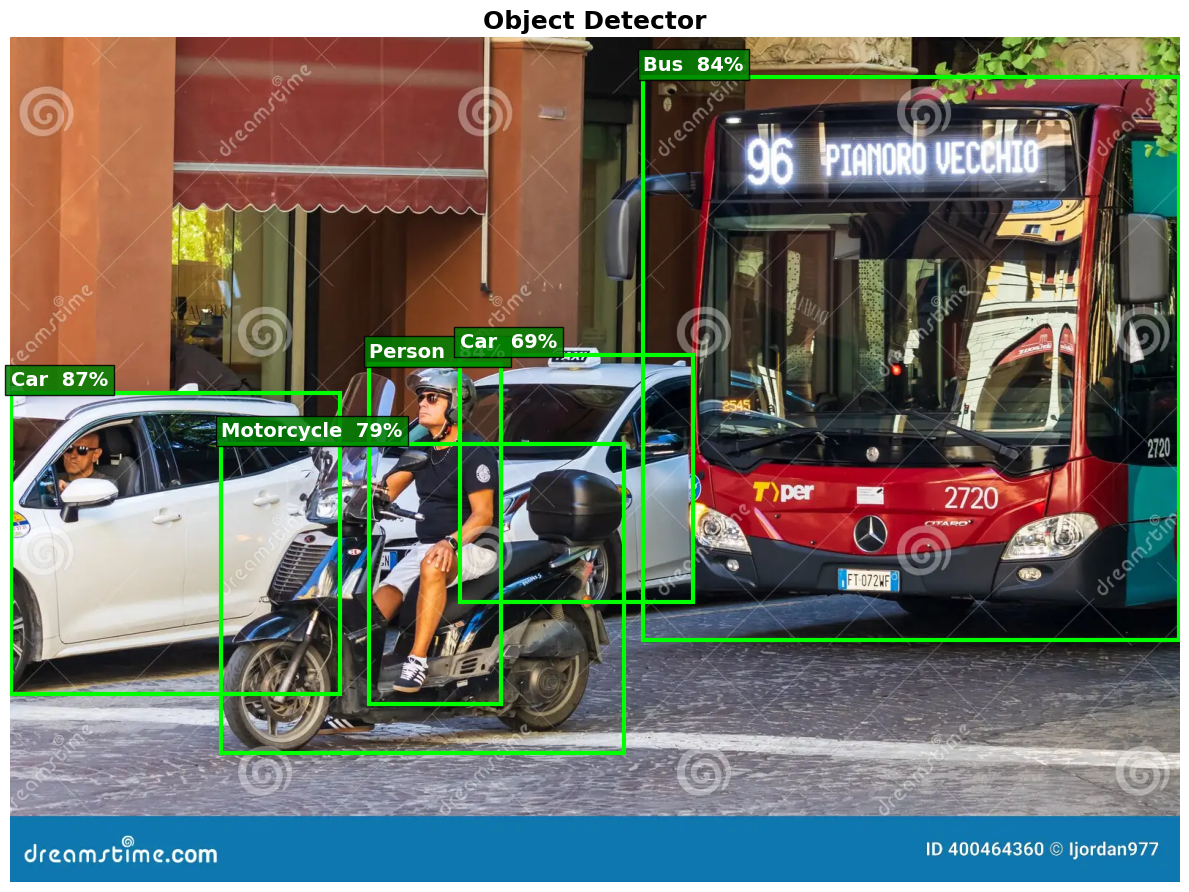

In [ ]:
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from google.colab import files

# Load YOLOv8 pre-trained model
model = YOLO("yolov8n.pt")  # nano model (fast)

# Upload your image here
print("Please upload an image file:")
uploaded = files.upload()
img_path = list(uploaded.keys())[0]  # Automatically picks the uploaded file

# Read input image and convert to RGB for matplotlib
image_bgr = cv2.imread(img_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Perform object detection
results = model(image_bgr)

# Set up matplotlib figure and axes
fig, ax = plt.subplots(1, figsize=(12, 9))
ax.imshow(image_rgb)

confidence_threshold = 0.4 # General confidence threshold for all objects

# Draw bounding boxes and labels
for result in results:
    for box in result.boxes:
        cls_id = int(box.cls)
        conf = float(box.conf)
        label = model.names[cls_id].lower()

        # Display all detected objects with confidence > confidence_threshold
        if conf > confidence_threshold:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            display_label = label.replace('_', ' ').title()

            # Draw rectangle
            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=3, edgecolor='lime', facecolor='none'
            )
            ax.add_patch(rect)

            # Add text label
            ax.text(
                x1, y1 - 10, f"{display_label}  {conf*100:.0f}%",
                color='white', fontsize=14, fontweight='bold',
                bbox=dict(facecolor='green', alpha=0.85, pad=4)
            )

ax.axis('off')
plt.title("Object Detector", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('output_objects.jpg', dpi=150, bbox_inches='tight')
plt.show()